<a href="https://colab.research.google.com/github/Nishant03-tech/PROJECT-EXHIBITION-1/blob/main/notebooks/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🫁 TB DETECTION SYSTEM
✅ TB_Detection project already exists.

📁 Project location: /content/TB_Detection
✅ Compatible trained model found.
🧠 Using: best_densenet121_compat.keras
✅ Prediction pipeline imported successfully.

📤 UPLOAD CHEST X-RAY IMAGE(S)


Saving tb1.png to tb1.png

✅ 1 image(s) uploaded.

🔍 ANALYZING: tb1.png

🧠 PREDICTION
------------------------------
Result       : TB
TB score     : 0.9964
TB score (%) : 99.64%

🔥 GRAD-CAM
------------------------------


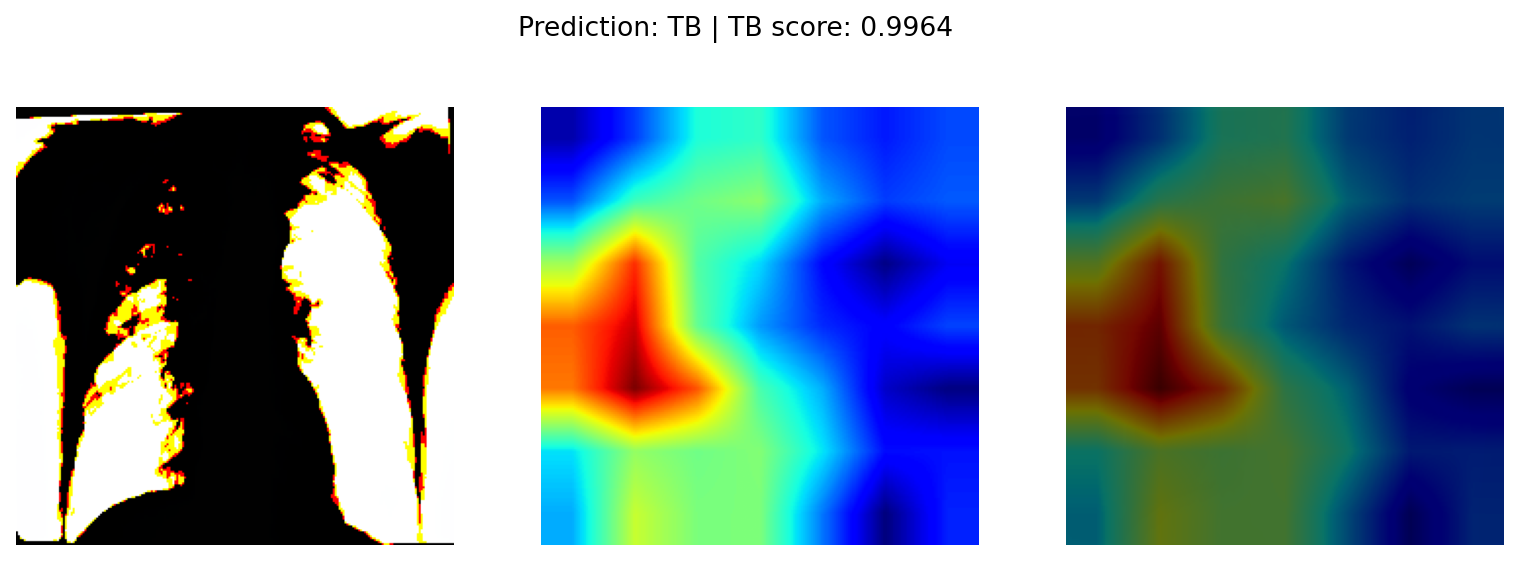




                    🫁 FINAL RESULTS
IMAGE                               PREDICTION      TB SCORE  
---------------------------------------------------------------------------
tb1.png                             TB              0.9964    

✅ PROCESS COMPLETED.
🚫 No model training was performed.
🧠 Existing trained DenseNet121 model was used.

⚠️ NOTE:
The TB score is a model output, not a calibrated clinical probability.
This is an academic/research prototype and not a medical diagnosis.


In [ ]:
import os
import sys
import zipfile
import json
import shutil

from google.colab import files
from IPython.display import Image, display

PROJECT_DIR = "/content/TB_Detection"

print("=" * 70)
print("🫁 TB DETECTION SYSTEM")
print("=" * 70)

if not os.path.exists(PROJECT_DIR):

    print("\n📦 Project files are not present.")
    print("Please upload: TB_Detection_project.zip\n")

    uploaded_project = files.upload()

    if not uploaded_project:
        raise RuntimeError("❌ No project ZIP was uploaded.")

    zip_name = next(iter(uploaded_project))

    print(f"\n✅ Project ZIP received: {zip_name}")
    print("📦 Extracting...")


    with zipfile.ZipFile(zip_name, "r") as zip_ref:
        zip_ref.extractall("/content")

    if not os.path.exists(PROJECT_DIR):

        possible_paths = [
            "/content/TB_Detection",
            "/content/TB_Detection_project/TB_Detection",
            "/content/TB Detection project/TB_Detection"
        ]

        found_path = None

        for path in possible_paths:
            if os.path.exists(path):
                found_path = path
                break

        if found_path is None:

            for root, dirs, files_in_folder in os.walk("/content"):

                if (
                    os.path.basename(root) == "TB_Detection"
                    and os.path.exists(os.path.join(root, "src"))
                    and os.path.exists(os.path.join(root, "models"))
                ):
                    found_path = root
                    break

        if found_path is None:
            raise FileNotFoundError(
                "❌ Could not find TB_Detection folder inside the ZIP."
            )

        if found_path != PROJECT_DIR:
            shutil.copytree(
                found_path,
                PROJECT_DIR,
                dirs_exist_ok=True
            )

    print("✅ Project extracted successfully.")

else:
    print("✅ TB_Detection project already exists.")

os.chdir(PROJECT_DIR)

print(f"\n📁 Project location: {PROJECT_DIR}")

models_folder = os.path.join(PROJECT_DIR, "models")

compat_model = os.path.join(
    models_folder,
    "best_densenet121_compat.keras"
)

original_model = os.path.join(
    models_folder,
    "best_densenet121.keras"
)

if os.path.exists(compat_model):

    MODEL_PATH = compat_model
    print("✅ Compatible trained model found.")
    print("🧠 Using:", os.path.basename(MODEL_PATH))

elif os.path.exists(original_model):

    print("\n⚙️ Creating compatible model...")
    print("⚠️ No retraining is being performed.")

    with zipfile.ZipFile(original_model, "r") as zin:

        model_files = {
            name: zin.read(name)
            for name in zin.namelist()
        }

    if "config.json" not in model_files:
        raise RuntimeError(
            "❌ config.json not found inside the Keras model."
        )

    config = json.loads(
        model_files["config.json"].decode("utf-8")
    )

    def fix_config(obj):

        if isinstance(obj, dict):

            if obj.get("class_name") == "GlorotUniform":

                cfg = obj.get("config", {})
                cfg.pop("input_axes", None)
                cfg.pop("output_axes", None)

            if obj.get("class_name") == "BatchNormalization":

                cfg = obj.get("config", {})
                cfg.pop("renorm", None)
                cfg.pop("renorm_clipping", None)
                cfg.pop("renorm_momentum", None)

            for value in obj.values():
                fix_config(value)

        elif isinstance(obj, list):

            for item in obj:
                fix_config(item)

    fix_config(config)

    model_files["config.json"] = json.dumps(
        config,
        separators=(",", ":")
    ).encode("utf-8")

    with zipfile.ZipFile(
        compat_model,
        "w",
        zipfile.ZIP_DEFLATED
    ) as zout:

        for name, data in model_files.items():
            zout.writestr(name, data)

    MODEL_PATH = compat_model

    print("✅ Compatible model created successfully.")
    print("🧠 Model:", MODEL_PATH)

else:

    raise FileNotFoundError(
        "❌ No trained DenseNet121 model found in models/"
    )

PIPELINE_FILE = os.path.join(
    PROJECT_DIR,
    "src",
    "tb_pipeline.py"
)

if not os.path.exists(PIPELINE_FILE):
    raise FileNotFoundError(
        "❌ src/tb_pipeline.py was not found."
    )

with open(
    PIPELINE_FILE,
    "r",
    encoding="utf-8"
) as f:
    pipeline_code = f.read()

pipeline_code = pipeline_code.replace(
    "best_densenet121.keras",
    "best_densenet121_compat.keras"
)

with open(
    PIPELINE_FILE,
    "w",
    encoding="utf-8"
) as f:
    f.write(pipeline_code)

if "src.tb_pipeline" in sys.modules:
    del sys.modules["src.tb_pipeline"]

from src.tb_pipeline import predict_xray

print("✅ Prediction pipeline imported successfully.")

print("\n" + "=" * 70)
print("📤 UPLOAD CHEST X-RAY IMAGE(S)")
print("=" * 70)

uploaded_images = files.upload()

if not uploaded_images:
    raise RuntimeError("❌ No X-ray image was uploaded.")

print(f"\n✅ {len(uploaded_images)} image(s) uploaded.")

results = []

for image_name in uploaded_images:

    image_path = os.path.abspath(image_name)

    print("\n" + "=" * 70)
    print(f"🔍 ANALYZING: {image_name}")
    print("=" * 70)

    try:

        result = predict_xray(image_path)

        predicted_class = result.get(
            "predicted_class",
            "Unknown"
        )

        tb_score = result.get(
            "tb_score",
            None
        )

        gradcam_path = result.get(
            "gradcam",
            None
        )

        results.append({
            "image": image_name,
            "prediction": predicted_class,
            "score": tb_score,
            "gradcam": gradcam_path
        })

        print("\n🧠 PREDICTION")
        print("------------------------------")
        print(f"Result       : {predicted_class}")

        if tb_score is not None:

            print(f"TB score     : {tb_score:.4f}")
            print(f"TB score (%) : {tb_score * 100:.2f}%")

        if (
            gradcam_path
            and os.path.exists(gradcam_path)
        ):

            print("\n🔥 GRAD-CAM")
            print("------------------------------")

            display(
                Image(
                    filename=gradcam_path
                )
            )

        else:
            print("\n⚠️ Grad-CAM image was not generated.")

    except Exception as e:

        print(f"\n❌ Error processing {image_name}:")
        print(str(e))

        results.append({
            "image": image_name,
            "prediction": "ERROR",
            "score": None,
            "gradcam": None
        })

print("\n\n")
print("=" * 75)
print("                    🫁 FINAL RESULTS")
print("=" * 75)

print(
    f"{'IMAGE':35} "
    f"{'PREDICTION':15} "
    f"{'TB SCORE':10}"
)

print("-" * 75)

for r in results:

    score = (
        f"{r['score']:.4f}"
        if r["score"] is not None
        else "N/A"
    )

    print(
        f"{r['image'][:35]:35} "
        f"{r['prediction']:15} "
        f"{score:10}"
    )

print("=" * 75)

print("\n✅ PROCESS COMPLETED.")
print("🚫 No model training was performed.")
print("🧠 Existing trained DenseNet121 model was used.")

print("\n⚠️ NOTE:")
print("The TB score is a model output, not a calibrated clinical probability.")
print("This is an academic/research prototype and not a medical diagnosis.")